install library for colab

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
from optuna import Trial

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Data scaning

In [52]:
data = pd.read_csv('./dataset/train.csv')
X = data.drop(columns=['rainfall'])
y = data['rainfall']
X_cp, y_cp = X.copy(), y.copy()
X_cp.head(10)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8
5,5,6,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,20.0,15.7
6,6,7,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,20.0,28.4
7,7,8,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,50.0,52.8
8,8,9,1017.4,17.6,16.5,15.6,12.5,86.0,100.0,0.0,50.0,37.5
9,9,10,1025.4,16.5,14.4,12.0,8.6,77.0,84.0,1.0,50.0,38.3


In [53]:
X_cp.shape

(2190, 12)

## 1. Check Null data

In [54]:
X_cp.isna().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

There is no Null data.

## 2. Check Duplicated data 

In [55]:
X_cp.duplicated().sum()

np.int64(0)

And no duplicated data

## 3 Check cardinulity

In [56]:
X_cp.nunique()

id               2190
day               365
pressure          236
maxtemp           219
temparature       198
mintemp           199
dewpoint          218
humidity           49
cloud              78
sunshine          120
winddirection      35
windspeed         223
dtype: int64

## 4. Check label's ratio

rainfall
1    0.75
0    0.25
Name: count, dtype: float64


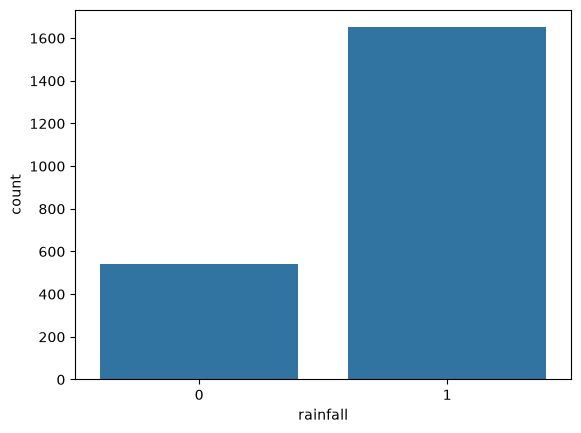

In [57]:
sns.countplot(x=y_cp)
ratio = np.round(y_cp.value_counts() / y_cp.value_counts().sum(), 2)
print(f'{ratio}')

- Note: There is class imbalance
- insight: We can do data augmetation (augment 0 class)

# Model selection

## Candidate Models

In [58]:
classifiers = {
    'Logistic_Regression' : LogisticRegression(random_state=42),
    'SVC' : SVC(random_state=42, probability=True),
    'XGBoost' : XGBClassifier(random_state=42, n_jobs=-1),
    'lgbm' : LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1),
    'Catboost' : CatBoostClassifier(random_state=42, verbose=0)
}

## Create data frame of performance

In [59]:
valid_score_df = pd.DataFrame({'classifier' : classifiers.keys(), 'validation_ROC_AUC_score' : np.zeros(len(classifiers))})
valid_score_df

,classifier,validation_ROC_AUC_score
0,Logistic_Regression,0.0
1,SVC,0.0
2,XGBoost,0.0
3,lgbm,0.0
4,Catboost,0.0


## Split data

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_cp, y_cp, random_state=42, test_size=0.3, stratify=y_cp)

### Normalize data

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Selecting best model

In [62]:
best_params = classifiers.copy()

def objective(trial, model_name):
    if model_name == 'Logistic_Regression':
        param = {
            'C': trial.suggest_float('C', 0.1, 1.5),
            'max_iter': trial.suggest_int('max_iter', 100, 200)
        }
    elif model_name == 'SVC':
        param = {
            'C': trial.suggest_float('C', 0.1, 1.5),
            'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
        }
    elif model_name == 'XGBoost':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1)
        }
    elif model_name == 'lgbm':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1)
        }
    elif model_name == 'Catboost':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1)
        }
    clf = clone(classifiers[model_name])
    clf.set_params(**param)

    KFOLD = 5
    cv = StratifiedKFold(n_splits=KFOLD, shuffle=True, random_state=42)
    total_score = 0
    for tr_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        smote = SMOTE(random_state=42)
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
        clf.fit(X_tr, y_tr)
        proba = clf.predict_proba(X_val)[:, 1]
        total_score += roc_auc_score(y_val, proba)
    total_score = total_score / KFOLD
    return total_score

for i, model_name in enumerate(classifiers.keys()):
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, model_name), n_trials=20)
    best_score = study.best_value
    best_param = study.best_params

    valid_score_df.iloc[i, 1] = best_score
    best_params[model_name] = best_param

[I 2026-06-29 09:16:39,660] A new study created in memory with name: no-name-4c561fd2-3695-4246-b2b1-2e2fca23f1c6
[I 2026-06-29 09:16:39,718] Trial 0 finished with value: 0.893718083086504 and parameters: {'C': 0.46403528728239274, 'max_iter': 172}. Best is trial 0 with value: 0.893718083086504.
[I 2026-06-29 09:16:39,777] Trial 1 finished with value: 0.8930907571960203 and parameters: {'C': 1.3653588254935967, 'max_iter': 137}. Best is trial 0 with value: 0.893718083086504.
[I 2026-06-29 09:16:39,833] Trial 2 finished with value: 0.893467000835422 and parameters: {'C': 0.5742940475324179, 'max_iter': 149}. Best is trial 0 with value: 0.893718083086504.
[I 2026-06-29 09:16:39,890] Trial 3 finished with value: 0.8939231411862991 and parameters: {'C': 0.33193192503600216, 'max_iter': 137}. Best is trial 3 with value: 0.8939231411862991.
[I 2026-06-29 09:16:39,944] Trial 4 finished with value: 0.8936383382699173 and parameters: {'C': 0.5212944620418672, 'max_iter': 172}. Best is trial 3 w

In [68]:
best_params

{'Logistic_Regression': {'C': 0.11213384428370743, 'max_iter': 103},
 'SVC': {'C': 0.18951549043243612, 'kernel': 'linear', 'gamma': 'scale'},
 'XGBoost': {'n_estimators': 58,
  'max_depth': 4,
  'learning_rate': 0.05024674569113391},
 'lgbm': {'n_estimators': 52,
  'max_depth': 4,
  'learning_rate': 0.06529461980813692},
 'Catboost': {'n_estimators': 89,
  'max_depth': 6,
  'learning_rate': 0.05199359972205558}}

In [63]:
valid_score_df

,classifier,validation_ROC_AUC_score
0,Logistic_Regression,0.894578
1,SVC,0.893626
2,XGBoost,0.882749
3,lgbm,0.884936
4,Catboost,0.891518


Logistic_Regression, SVC, Catboost was best models

# Modeling

In [91]:
best_models = {
    'Logistic_Regression' : LogisticRegression(random_state=42),
    'SVC' : SVC(random_state=42, probability=True),
    'Catboost' : CatBoostClassifier(random_state=42, verbose=0)
}
preds = np.zeros(len(X_test))

for model_name, model in best_models.items():
    clf = best_models[model_name].set_params(**best_params[model_name])
    smote = SMOTE(random_state=42)
    X_tr, y_tr = smote.fit_resample(X_train_scaled, y_train)
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_test_scaled)[:,1]
    preds += proba
    score = np.round(roc_auc_score(y_test, proba), 4)
    print(f'{model_name} score : {score}')
ensemble_score = roc_auc_score(y_test, preds / len(best_models))
print(f'ensemble model score : {np.round(ensemble_score ,4)}')


Logistic_Regression score : 0.8925
SVC score : 0.8884
Catboost score : 0.889
ensemble model score : 0.8922


The best model is Logistic regression model

## Set threshold

In [ ]:
model = LogisticRegression(random_state=42).set_params(**best_params['Logistic_Regression'])
model.fit(X_train_scaled, y_train)
proba = model.predict_proba(X_test_scaled)[:,1]
mean = np.round(proba.mean(), 4)
goal_ratio = np.round(data['rainfall'].sum()/len(data), 4)
print(ratio)
print(mean)


0.7534
0.7681
